# Prediction Irrigation Need

## Imports and configs

In [1]:
# ======================
# IMPORTS
# ======================

import math

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.tree import DecisionTreeClassifier
import mlflow

from lightgbm import LGBMClassifier, log_evaluation, early_stopping
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import AgglomerativeClustering

import importlib
import utils
importlib.reload(utils)
from utils import load_and_clean_df, show_overview, lightgbm_check, linear_models_check, feature_interpretability

In [2]:
# ======================
# CONFIG
# ======================

pd.set_option("display.max_columns", None)

# mlflow configs
mlflow.set_tracking_uri("http://127.0.0.1:5000")
project_name = "Predict_Irrigation_Need"
mlflow.set_experiment(project_name)
mlflow.lightgbm.autolog()

%xmode Context

# Constants
TARGET = "Irrigation_Need"

Exception reporting mode: Context


## EDA
* Overview structure:
  + n_count = 2: binary
  + ordinal encoder != label encoder
* Missing values
* Missing strategy
* Target analysis
* Feature types
* Distribution (features)
* Feature vs Target
* Correlation
* Leakage check
* Quick model check

In [3]:
# ======================
# Overview structure
#
# mulching_used is binary col, use one-hot in linear and Label/Boolean in others
# 
# ======================

# Load df
df = load_and_clean_df('../Data/PredictingIrrigationNeed/train.csv')

show_overview(df)

,soil_type,soil_ph,soil_moisture,organic_carbon,electrical_conductivity,temperature_c,humidity,rainfall_mm,sunlight_hours,wind_speed_kmh,crop_type,crop_growth_stage,season,irrigation_type,water_source,field_area_hectare,mulching_used,previous_irrigation_mm,region,irrigation_need
dtype,category,float64,float64,float64,float64,float64,float64,float64,float64,float64,category,category,category,category,category,float64,category,float64,category,category
non_null,630000,630000,630000,630000,630000,630000,630000,630000,630000,630000,630000,630000,630000,630000,630000,630000,630000,630000,630000,630000
null_%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
nunique,4,341,5223,131,341,2934,6475,19308,701,1935,6,4,3,4,4,1466,2,10110,5,3
0,Loamy,4.920000,32.580000,1.010000,3.050000,15.010000,50.610000,725.990000,5.900000,16.790000,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.820000,No,112.160000,East,Low
1,Clay,7.080000,56.610000,0.440000,2.000000,22.920000,67.860000,985.660000,6.980000,3.390000,Wheat,Vegetative,Kharif,Rainfed,River,5.270000,Yes,47.160000,South,Low
2,Clay,5.690000,27.710000,0.810000,2.830000,26.970000,92.220000,2201.700000,6.050000,3.850000,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.240000,Yes,110.380000,North,Low
3,Sandy,5.650000,13.320000,1.330000,0.870000,13.320000,61.570000,1357.330000,9.120000,2.310000,Wheat,Flowering,Kharif,Canal,River,8.320000,Yes,53.850000,South,Medium
4,Clay,7.960000,59.140000,0.380000,0.960000,20.220000,91.110000,1538.200000,6.950000,13.940000,Wheat,Sowing,Rabi,Canal,River,7.370000,No,93.190000,South,Low


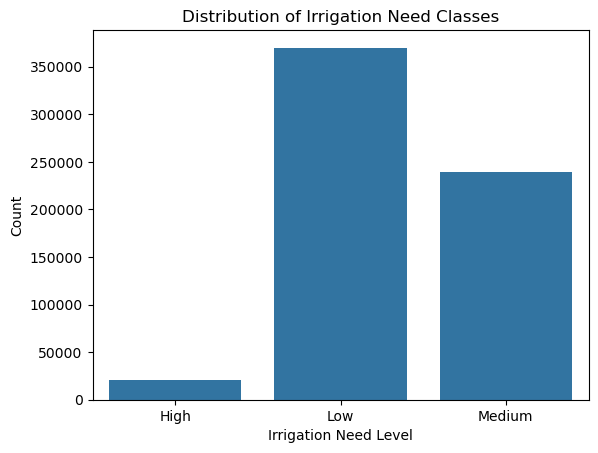

irrigation_need
Low       0.587170
Medium    0.379483
High      0.033348
Name: proportion, dtype: float64

In [4]:
# ======================
# Target Variable Analysis: Irrigation Need Classification
#
# Objective: Understand the distribution of the target variable to assess class imbalance,
# which critically impacts model performance and evaluation strategies.
#
# Key Insights:
# - Class imbalance can lead to biased models favoring majority classes.
# - Strategies: Use balanced class weights, resampling (SMOTE/undersampling), or metrics like F1-score/AUC instead of accuracy.
# - Visualization: Count plot reveals frequency; normalized value_counts show proportions.
# ======================

TARGET = 'irrigation_need'

# Visualize class distribution with count plot
# - X-axis: Target classes (e.g., 'Low', 'Medium', 'High' irrigation needs)
# - Y-axis: Absolute counts per class
# - Interpretation: Identifies dominant classes and potential imbalance severity
sns.countplot(x=df[TARGET])
plt.title('Distribution of Irrigation Need Classes')
plt.xlabel('Irrigation Need Level')
plt.ylabel('Count')
plt.show()

# Quantitative analysis: Normalized value counts
# - Returns proportions (0-1) for each class
# - Helps quantify imbalance ratio (e.g., minority class < 10% may require special handling)
# - Use for baseline expectations and resampling decisions
df[TARGET].value_counts(normalize=True)

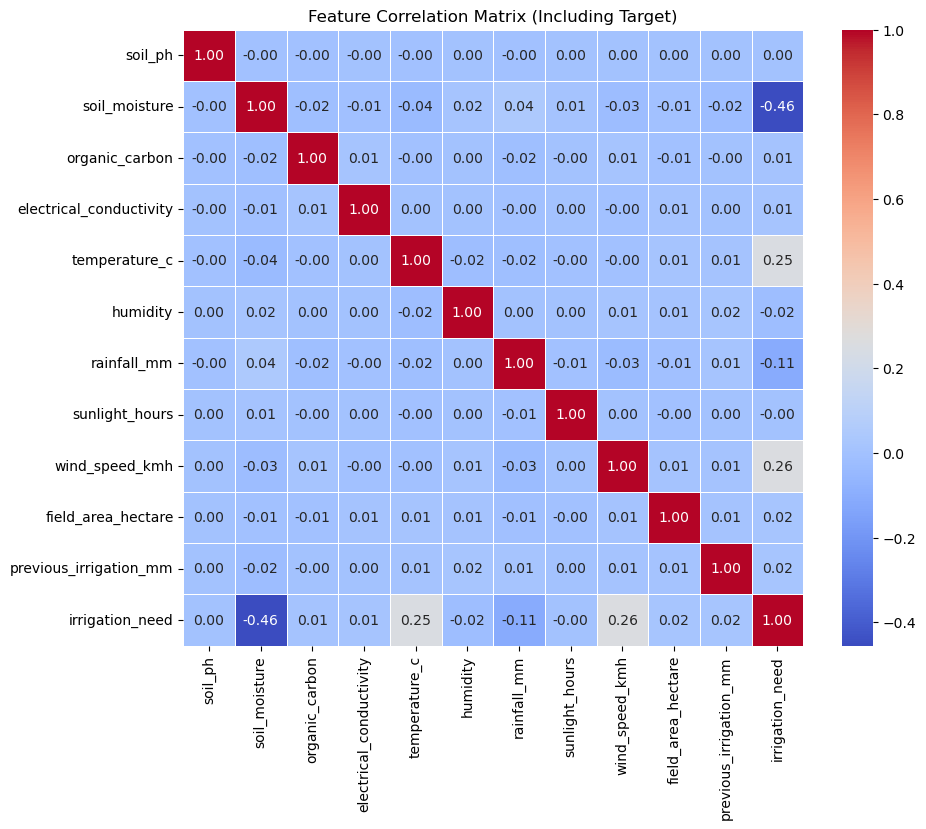

In [5]:
# ======================
# Feature Correlation Analysis
#
# Purpose: Examine linear relationships between numerical features and the target variable
# to identify potential predictors, multicollinearity, and feature engineering opportunities.
#
# Methodology:
# - Encode target as ordinal (Low=0, Medium=1, High=2) for correlation computation.
# - Include only numerical columns (categorical features excluded to avoid encoding complexity).
# - Compute Pearson correlation matrix.
# - Visualize with heatmap for intuitive interpretation.
#
# Interpretation Guidelines:
# - Correlation coefficients range from -1 to 1.
# - |r| > 0.7: Strong correlation (potential multicollinearity or key predictors).
# - |r| 0.3-0.7: Moderate correlation (useful for feature selection).
# - |r| < 0.3: Weak correlation (may not be predictive alone).
# - Focus on target correlations for feature importance; check feature-feature correlations for redundancy.
#
# Expected Insights: Real-world data often shows weak correlations; combine with domain knowledge and non-linear methods.
# ======================

df[TARGET] = df[TARGET].map({'Low': 0, 'Medium': 1, 'High': 2})

# Select numerical columns for correlation analysis
# - Excludes categorical features to focus on quantitative relationships
num_cols = df.select_dtypes(include=np.number).columns

# Include target in correlation matrix
# - Allows assessment of feature-target relationships
num_plus_target = num_cols.tolist()
num_plus_target.append(TARGET)

# Compute correlation matrix
# - Uses Pearson correlation by default (linear relationships)
corr = df[num_plus_target].corr()

# Visualize correlations with heatmap
# - Color scale: Red (positive), Blue (negative), White (neutral)
# - Annotations show exact coefficients for precision
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix (Including Target)')
plt.show()

### Lightgbm quick check

2026/05/07 11:02:35 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '8f7f3b6d0f454a179e58416ee97afc50', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current lightgbm workflow


Training until validation scores don't improve for 100 rounds
[50]	train's multi_logloss: 0.0880603	valid's multi_logloss: 0.0814106
[100]	train's multi_logloss: 0.0684214	valid's multi_logloss: 0.0717696
[150]	train's multi_logloss: 0.0585904	valid's multi_logloss: 0.0677272
[200]	train's multi_logloss: 0.0519644	valid's multi_logloss: 0.0657338
[250]	train's multi_logloss: 0.0465882	valid's multi_logloss: 0.0638426
[300]	train's multi_logloss: 0.0422521	valid's multi_logloss: 0.0626393
[350]	train's multi_logloss: 0.0390444	valid's multi_logloss: 0.062657
[400]	train's multi_logloss: 0.0358104	valid's multi_logloss: 0.0619658
[450]	train's multi_logloss: 0.0331145	valid's multi_logloss: 0.0614262
[500]	train's multi_logloss: 0.0306824	valid's multi_logloss: 0.0610042
[550]	train's multi_logloss: 0.0285186	valid's multi_logloss: 0.0606606
[600]	train's multi_logloss: 0.0264868	valid's multi_logloss: 0.0604326
[650]	train's multi_logloss: 0.0246886	valid's multi_logloss: 0.0602247
[700

2026/05/07 11:03:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 11:03:20 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run fortunate-quail-204 at: http://127.0.0.1:5000/#/experiments/1/runs/8f7f3b6d0f454a179e58416ee97afc50
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


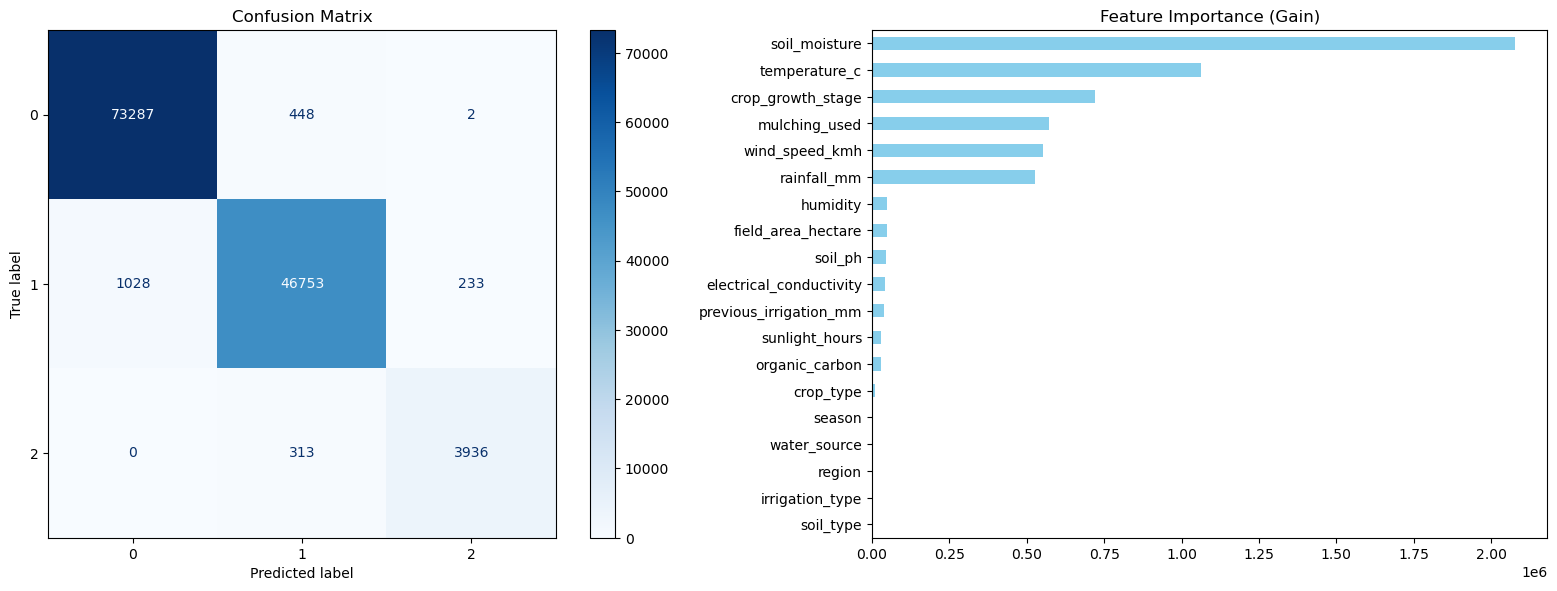

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     73737
           1       0.98      0.97      0.98     48014
           2       0.94      0.93      0.93      4249

    accuracy                           0.98    126000
   macro avg       0.97      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000



In [ ]:
# ======================
# Quick lightGBM model check
#
# Purpose: Perform a rapid baseline evaluation of a LightGBM classifier on the dataset 
# to identify initial performance and potential issues (e.g., class imbalance, feature importance).
# ======================

importlib.reload(utils)
from utils import load_and_clean_df, show_overview, lightgbm_check, linear_models_check, feature_interpretability

X = df.drop(TARGET, axis=1)
y = df[TARGET]

train_test_set = train_test_split(X, y, test_size=.2, random_state=42)
lightgbm_check(train_test_set)


In [11]:
# ======================
# Linear model comparison check
#
# Purpose: Compare baseline linear classifiers on the same train/test split
# to see whether a linear separator or logistic classifier can compete with tree-based models.
# ======================

# Example usage:
linear_models_check(train_test_set)


=== LinearSVC ===
              precision    recall  f1-score   support

           0       0.91      0.91      0.91     73737
           1       0.81      0.86      0.83     48014
           2       0.80      0.37      0.51      4249

    accuracy                           0.87    126000
   macro avg       0.84      0.71      0.75    126000
weighted avg       0.87      0.87      0.87    126000

🏃 View run LinearModels_LinearSVC at: http://127.0.0.1:5000/#/experiments/1/runs/acfc9921751b44bca48d6450f0f135f4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/nguyen/micromamba/envs/ai/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== LogisticRegression ===
              precision    recall  f1-score   support

           0       0.93      0.88      0.91     73737
           1       0.80      0.78      0.79     48014
           2       0.38      0.88      0.53      4249

    accuracy                           0.84    126000
   macro avg       0.71      0.85      0.74    126000
weighted avg       0.86      0.84      0.85    126000

🏃 View run LinearModels_LogisticRegression at: http://127.0.0.1:5000/#/experiments/1/runs/541225b544dc4c1c960912d410c6fdfc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,LinearSVC,0.869762,0.869998,0.869762,0.866989
1,LogisticRegression,0.841659,0.864455,0.841659,0.849201


,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,LinearSVC,0.869762,0.869998,0.869762,0.866989
1,LogisticRegression,0.841659,0.864455,0.841659,0.849201


,feature,logistic_coef,cluster
1,soil_moisture,-3.848773e-15,0
8,wind_speed_kmh,-2.886580e-15,0
4,temperature_c,1.036208e-15,0
27,season_Zaid,-5.736152e-16,0
14,soil_type_Silt,-5.551115e-16,0
25,season_Kharif,5.551115e-16,0
33,water_source_Rainwater,-5.366078e-16,0
6,rainfall_mm,5.181041e-16,0
35,water_source_River,-4.625929e-16,0
20,crop_type_Wheat,4.533411e-16,0


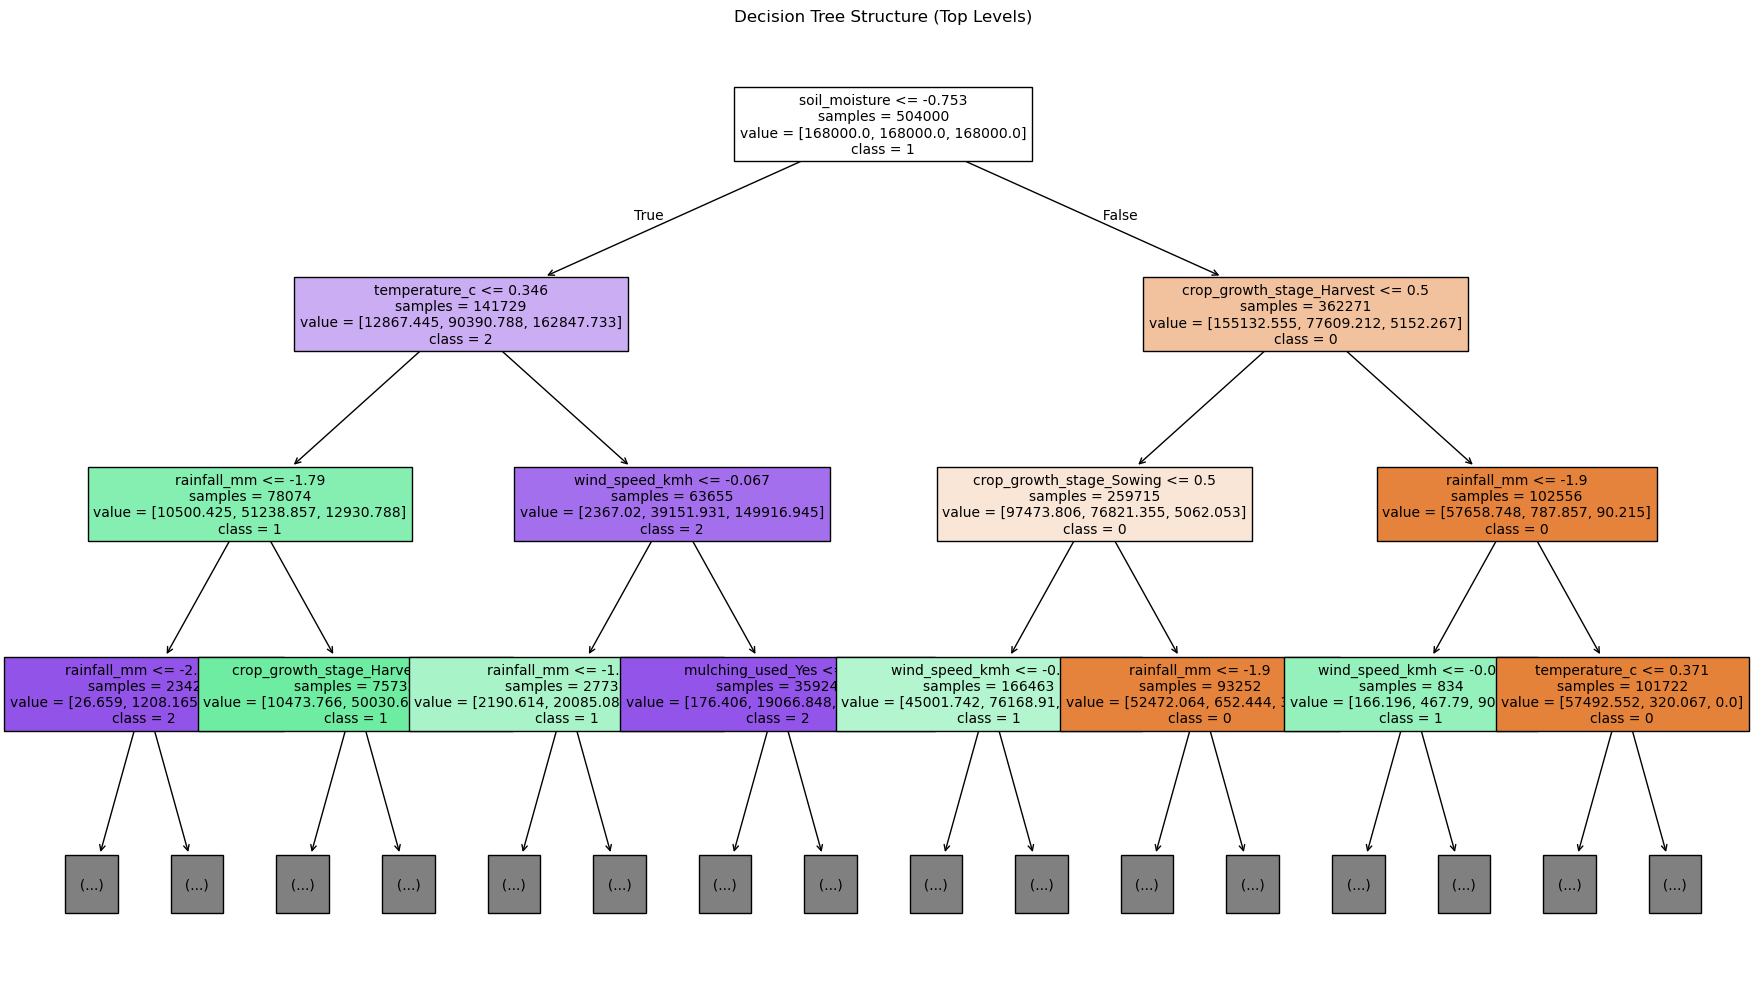

In [8]:
feature_interpretability(train_test_set)

## Feature Engineering
* Data spliting (Prevent data leakage)
* Imputation (Clean)
* Feature Engineering (Create useful features)
  + Put numerical cols into bins
  + Combine categorical cols
  + Groupby(COL1)[COL2].agg(STAT)
  + Target Encoding is Most Powerful
  + Groupby(COL1)['Price'].agg(“mean”)
  + Groupby(COL1)['Price'].agg(HISTOGRAM BINS)
  + Groupby(COL1)['Price'].agg(QUANTILES)
* Target Resampling
* Feature scaling & normalization
* Feature Selection

In [54]:
# ======================
# Data spliting
# ======================


X = df.drop(TARGET, axis=1)
y = df[TARGET]

show_overview(X)

X_train, X_test, y_train, y_test = train_test_split(X, y)

,soil_type,soil_ph,soil_moisture,organic_carbon,electrical_conductivity,temperature_c,humidity,rainfall_mm,sunlight_hours,wind_speed_kmh,crop_type,crop_growth_stage,season,irrigation_type,water_source,field_area_hectare,mulching_used,previous_irrigation_mm,region
dtype,category,float64,float64,float64,float64,float64,float64,float64,float64,float64,category,category,category,category,category,float64,category,float64,category
non_null,630000,630000,630000,630000,630000,630000,630000,630000,630000,630000,630000,630000,630000,630000,630000,630000,630000,630000,630000
null_%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
nunique,4,341,5223,131,341,2934,6475,19308,701,1935,6,4,3,4,4,1466,2,10110,5
0,Loamy,4.920000,32.580000,1.010000,3.050000,15.010000,50.610000,725.990000,5.900000,16.790000,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.820000,No,112.160000,East
1,Clay,7.080000,56.610000,0.440000,2.000000,22.920000,67.860000,985.660000,6.980000,3.390000,Wheat,Vegetative,Kharif,Rainfed,River,5.270000,Yes,47.160000,South
2,Clay,5.690000,27.710000,0.810000,2.830000,26.970000,92.220000,2201.700000,6.050000,3.850000,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.240000,Yes,110.380000,North
3,Sandy,5.650000,13.320000,1.330000,0.870000,13.320000,61.570000,1357.330000,9.120000,2.310000,Wheat,Flowering,Kharif,Canal,River,8.320000,Yes,53.850000,South
4,Clay,7.960000,59.140000,0.380000,0.960000,20.220000,91.110000,1538.200000,6.950000,13.940000,Wheat,Sowing,Rabi,Canal,River,7.370000,No,93.190000,South


### Binning

In [52]:
class TreeBinner(BaseEstimator, TransformerMixin):
    def __init__(self, max_leaf_nodes=5):
        self.max_leaf_nodes = max_leaf_nodes
        self.models = {}

    def fit(self, X, y):
        X = pd.DataFrame(X)
        num_cols = X.select_dtypes(include=np.number).columns
        for col in num_cols:
            model = DecisionTreeClassifier(max_leaf_nodes=self.max_leaf_nodes)
            model.fit(X[[col]], y)
            self.models[col] = model
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in self.models:
            model = self.models[col]
            X[col + "_bin"] = model.apply(X[[col]])
            X[col + "_bin"] = X[col + "_bin"].astype('category')
        return X
    
    def get_feature_names_out(self, input_features=None):
        input_features = list(input_features)
        new_features = [f"{col}_bin" for col in input_features]
        return input_features + new_features

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), make_column_selector(dtype_exclude=np.number)),
    ('num', StandardScaler(), make_column_selector(dtype_include=np.number))
])

pipeline = Pipeline([
    ('binner', TreeBinner(max_leaf_nodes=5)),
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

def evaluate(pipeline, X, y):
    scores = cross_val_score(pipeline, X, y, cv=5)
    return scores.mean(), scores.std()

eval_mean, eval_std = evaluate(pipeline, X, y)

In [55]:
eval_mean, eval_std

(np.float64(0.9845888888888888), np.float64(0.00018534082650690104))

In [56]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), make_column_selector(dtype_exclude=np.number)),
    ('num', StandardScaler(), make_column_selector(dtype_include=np.number))
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

def evaluate(pipeline, X, y):
    scores = cross_val_score(pipeline, X, y, cv=5)
    return scores.mean(), scores.std()

eval_mean, eval_std = evaluate(pipeline, X, y)

eval_mean, eval_std

(np.float64(0.9848476190476191), np.float64(0.0002552744189583903))

### Combine categorical

In [ ]:
class CatCombiner(BaseEstimator, TransformerMixin):
    def __init__(self, cols_to_combine):
        self.cols_to_combine = cols_to_combine

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X['combined'] = X[self.cols_to_combine].astype(str).agg('-'.join, axis=1)
        return X
    
    def get_feature_names_out(self, input_features=None):
        input_features = list(input_features)
        new_feature = 'combined'
        return input_features + [new_feature]

show_overview(df.select_dtypes(exclude=np.number))

,soil_type,crop_type,crop_growth_stage,season,irrigation_type,water_source,mulching_used,region,irrigation_need
dtype,category,category,category,category,category,category,category,category,category
non_null,630000,630000,630000,630000,630000,630000,630000,630000,630000
null_%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
nunique,4,6,4,3,4,4,2,5,3
0,Loamy,Sugarcane,Sowing,Zaid,Drip,Rainwater,No,East,0
1,Clay,Wheat,Vegetative,Kharif,Rainfed,River,Yes,South,0
2,Clay,Rice,Vegetative,Kharif,Sprinkler,Reservoir,Yes,North,0
3,Sandy,Wheat,Flowering,Kharif,Canal,River,Yes,South,1
4,Clay,Wheat,Sowing,Rabi,Canal,River,No,South,0


## Modeling

In [22]:
from sklearn.ensemble import StackingClassifier

# Method 2: Using sklearn.ensemble.StackingClassifier
print("\n" + "="*50)
print("METHOD 2: USING StackingClassifier")
print("="*50)

# Define base learners
base_learners_sklearn = [
    ('lr', LogisticRegression(random_state=42, max_iter=200)),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
]

# Define meta-learner
meta_learner_sklearn = LogisticRegression(random_state=42, max_iter=200)

# Create StackingClassifier
stacking_clf = StackingClassifier(
    estimators=base_learners_sklearn,
    final_estimator=meta_learner_sklearn,
    cv=5  # 5-fold cross-validation for generating meta-features
)

# Train the stacking classifier
stacking_clf.fit(X_train_scaled, y_train)

# Make predictions
y_pred_stacking = stacking_clf.predict(X_test_scaled)
y_pred_proba = stacking_clf.predict_proba(X_test_scaled)

# Evaluate
accuracy_stacking = accuracy_score(y_test, y_pred_stacking)
print(f"Stacking Classifier Accuracy: {accuracy_stacking:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_stacking))


METHOD 2: USING StackingClassifier
Stacking Classifier Accuracy: 0.9550

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.96       106
           1       0.94      0.97      0.95        94

    accuracy                           0.95       200
   macro avg       0.95      0.96      0.95       200
weighted avg       0.96      0.95      0.96       200




MODEL COMPARISON
lr: 0.8250
dt: 0.7900
svm: 0.9400
Stacking: 0.9550


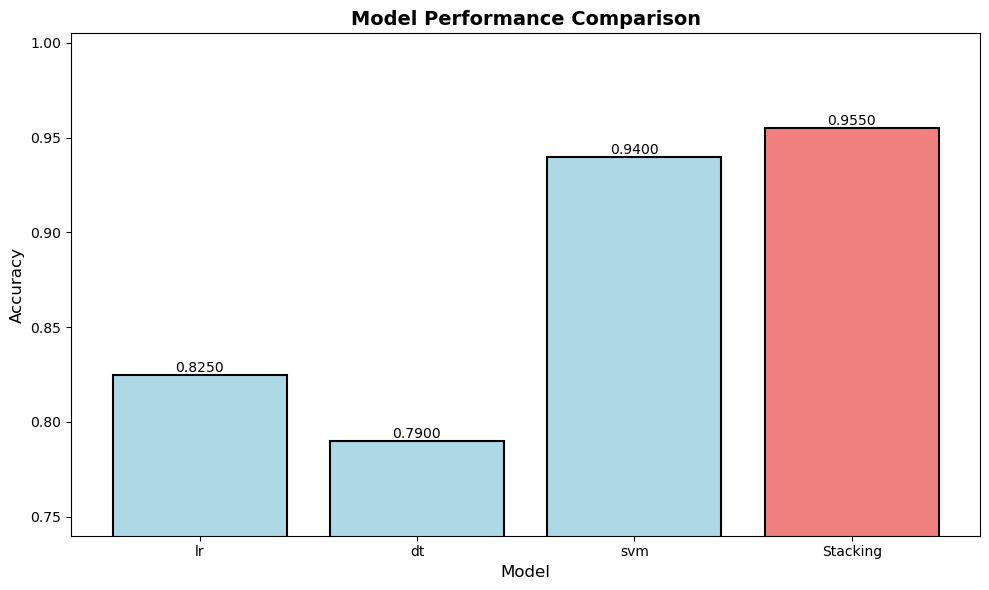

In [23]:
# Comparison of individual models vs stacking
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

results = {}

# Individual base learners
for name, model in base_learners_sklearn:
    model.fit(X_train_scaled, y_train)
    y_pred_individual = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_individual)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

# Add stacking result
results['Stacking'] = accuracy_stacking
print(f"Stacking: {accuracy_stacking:.4f}")

# Visualize comparison
plt.figure(figsize=(10, 6))
models = list(results.keys())
accuracies = list(results.values())
colors = ['lightblue', 'lightblue', 'lightblue', 'lightcoral']

bars = plt.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylim([min(accuracies) - 0.05, max(accuracies) + 0.05])

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

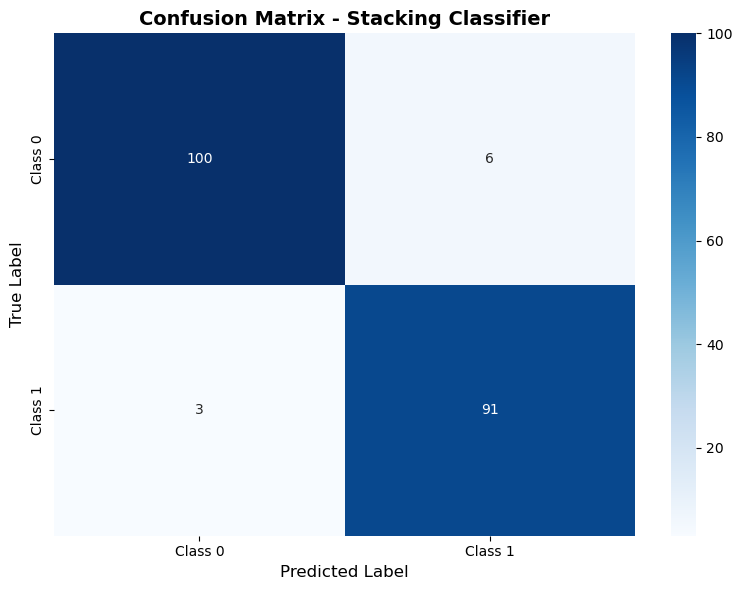

True Negatives: 100
False Positives: 6
False Negatives: 3
True Positives: 91


In [24]:
# Confusion Matrix for Stacking Model
cm = confusion_matrix(y_test, y_pred_stacking)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.title('Confusion Matrix - Stacking Classifier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"True Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

## Key Concepts of Stacking

### What is Stacking?
Stacking is an ensemble learning technique that combines multiple diverse models to improve predictive performance. The key idea is:

1. **Base Learners (Level 0)**: Train multiple diverse models (e.g., Logistic Regression, Decision Tree, SVM)
2. **Meta-Features**: Use predictions from base learners as input features
3. **Meta-Learner (Level 1)**: Train a final model using meta-features to make the final prediction

### Advantages:
- ✅ Combines strengths of diverse algorithms
- ✅ Reduces overfitting compared to individual models
- ✅ Often achieves higher accuracy than individual base learners
- ✅ Works with different types of models (regression, classification)

### Process:
1. Split data into training and testing sets
2. Train multiple diverse base learners on training data
3. Generate predictions (meta-features) from base learners
4. Train meta-learner on meta-features and original labels
5. For final prediction: base learners predict → meta-learner predicts final output

### When to use:
- When you have diverse models with different strengths
- When individual models have good but not perfect accuracy
- When you need improved generalization on unseen data